# Task 3: Anomaly Detection in Sensor Data using Wavelets

**Lab 06 solution**  
Run cells from top to bottom. Change only the paths in the configuration cell when using your own media.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def show(img, title='', cmap=None, size=(12,7)):
    plt.figure(figsize=size)
    if img.ndim == 3:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or 'gray')
    plt.title(title); plt.axis('off'); plt.show()

In [6]:
import pywt
np.random.seed(42)
import numpy as np


# ============================================================
# Generate / Load Sensor Signal
# ============================================================

np.random.seed(42)

N = 1000
t = np.arange(N)

# ------------------------------------------------------------
# Option 1: Load real sensor data
# ------------------------------------------------------------
# signal = np.loadtxt(
#     'sensor.csv',
#     delimiter=',',
#     skiprows=1,
#     usecols=1
# )

# ------------------------------------------------------------
# Option 2: Generate synthetic sensor signal
# ------------------------------------------------------------

signal = (
    0.45 * np.sin(2 * np.pi * t / 90)
    + 0.18 * np.sin(2 * np.pi * t / 19)
    + 0.22 * np.random.randn(N)
)


# ============================================================
# Inject Known Anomalies
# ============================================================

true_anomalies = np.array([
    170,
    171,
    425,
    700,
    701,
    850
])

anomaly_values = np.array([
    2.8,
    2.1,
    -3.0,
    2.5,
    2.0,
    -2.7
])

signal[true_anomalies] += anomaly_values


# ============================================================
# Basic Information
# ============================================================

print("Signal length:", len(signal))
print("True anomaly indices:", true_anomalies)

# Replace this line with: signal=np.loadtxt('sensor.csv',delimiter=',',skiprows=1,usecols=1)
signal=0.45*np.sin(2*np.pi*t/90)+0.18*np.sin(2*np.pi*t/19)+0.22*np.random.randn(N)
true_anomalies=np.array([170,171,425,700,701,850])
signal[true_anomalies] += np.array([2.8,2.1,-3.0,2.5,2.0,-2.7])

Signal length: 1000
True anomaly indices: [170 171 425 700 701 850]


In [7]:
# ============================================================
# Wavelet Denoising + Anomaly Detection
# ============================================================

wavelet = 'db4'
level = 4

# ------------------------------------------------------------
# Wavelet decomposition
# ------------------------------------------------------------

coeffs = pywt.wavedec(
    signal,
    wavelet,
    level=level
)

# ------------------------------------------------------------
# Estimate noise using the highest-frequency detail
# coefficients.
# ------------------------------------------------------------

sigma = (
    np.median(np.abs(coeffs[-1]))
    / 0.6745
)

threshold = (
    sigma
    * np.sqrt(2 * np.log(len(signal)))
)

# ------------------------------------------------------------
# Apply soft thresholding to detail coefficients
# ------------------------------------------------------------

denoised_coeffs = [
    coeffs[0]
]

denoised_coeffs += [
    pywt.threshold(
        c,
        threshold,
        mode='soft'
    )
    for c in coeffs[1:]
]

# ------------------------------------------------------------
# Reconstruct denoised signal
# ------------------------------------------------------------

denoised = pywt.waverec(
    denoised_coeffs,
    wavelet
)[:len(signal)]

# Calculate residual

residual = signal - denoised

# Robust residual statistics using MAD

residual_median = np.median(residual)

mad = np.median(
    np.abs(
        residual - residual_median
    )
)

robust_sigma = 1.4826 * mad

# Detect anomalies

anomaly_threshold = (
    3.5 * robust_sigma
)

anomaly_mask = (
    np.abs(
        residual - residual_median
    )
    > anomaly_threshold
)

idx = np.where(
    anomaly_mask
)[0]

# Results

print(
    "Wavelet threshold:",
    round(threshold, 4)
)

print(
    "Robust residual sigma:",
    round(robust_sigma, 4)
)

print(
    "Anomaly threshold:",
    round(anomaly_threshold, 4)
)

print(
    "Detected anomaly indices:",
    idx.tolist()
)


Wavelet threshold: 0.8001
Robust residual sigma: 0.2522
Anomaly threshold: 0.8828
Detected anomaly indices: [170, 171, 425, 700, 701, 850]


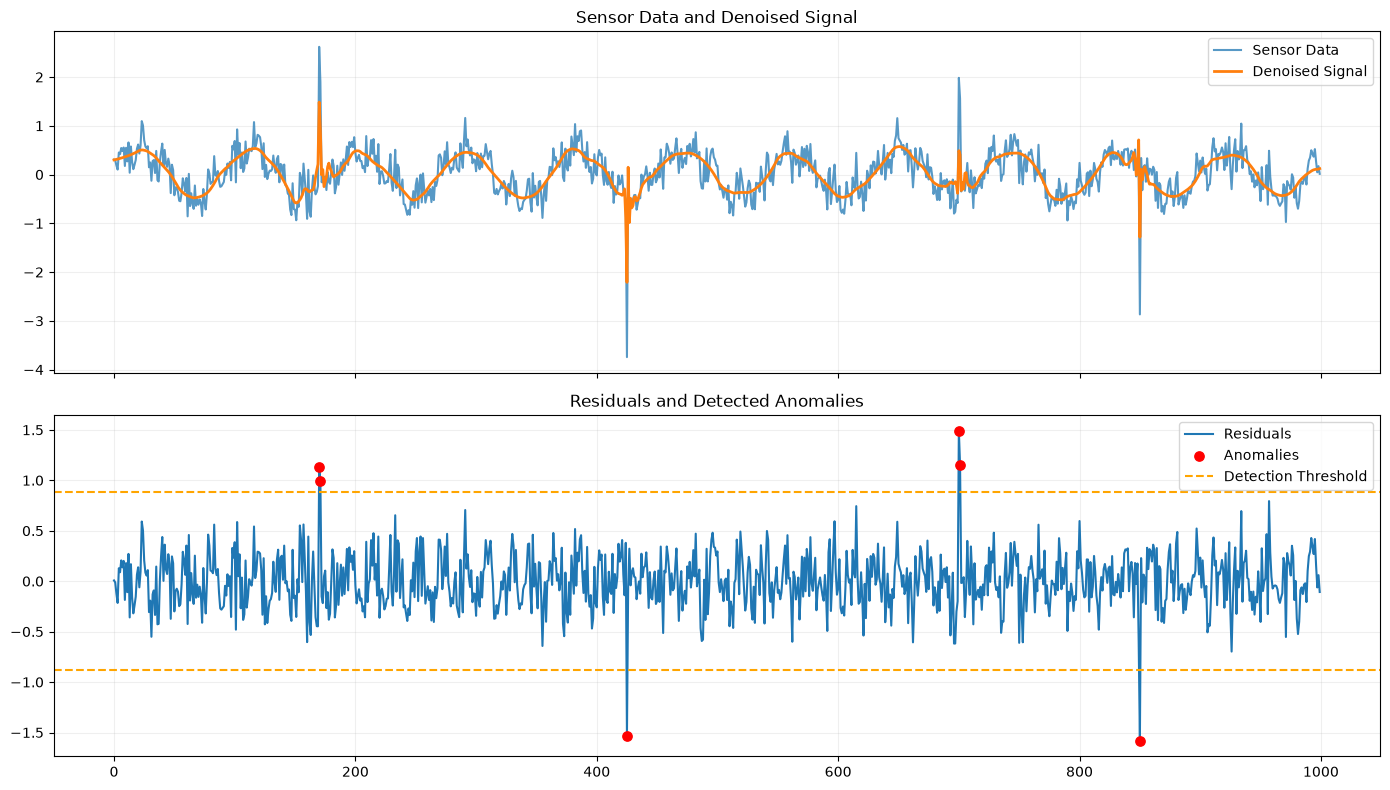

In [8]:
# ============================================================
# Visualize Wavelet Anomaly Detection
# ============================================================

fig, ax = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True
)


# ============================================================
# Plot 1: Original and Denoised Signal
# ============================================================

ax[0].plot(
    signal,
    label='Sensor Data',
    alpha=0.75
)

ax[0].plot(
    denoised,
    label='Denoised Signal',
    linewidth=2
)

ax[0].set_title(
    'Sensor Data and Denoised Signal'
)

ax[0].legend()
ax[0].grid(
    alpha=0.2
)


# ============================================================
# Plot 2: Residuals and Detected Anomalies
# ============================================================

ax[1].plot(
    residual,
    label='Residuals'
)

ax[1].scatter(
    idx,
    residual[idx],
    color='red',
    s=45,
    label='Anomalies',
    zorder=3
)

# Positive anomaly threshold
ax[1].axhline(
    anomaly_threshold,
    color='orange',
    linestyle='--',
    label='Detection Threshold'
)

# Negative anomaly threshold
ax[1].axhline(
    -anomaly_threshold,
    color='orange',
    linestyle='--'
)

ax[1].set_title(
    'Residuals and Detected Anomalies'
)

ax[1].legend()
ax[1].grid(
    alpha=0.2
)


# ============================================================
# Final layout and save
# ============================================================

plt.tight_layout()

plt.savefig(
    'task3_wavelet_anomalies.png',
    dpi=180
)

plt.show()


## Method
A `db4` discrete wavelet decomposition separates slow machine behavior from short disturbances. Soft thresholding denoises the detail coefficients. Samples whose residual exceeds **3.5 robust standard deviations** are marked anomalous. For a real dataset, replace the synthetic-signal line with the provided CSV column.